### import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

## Initial Exploration

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.shape

(7043, 21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Check Target Variable Distribution

In [12]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

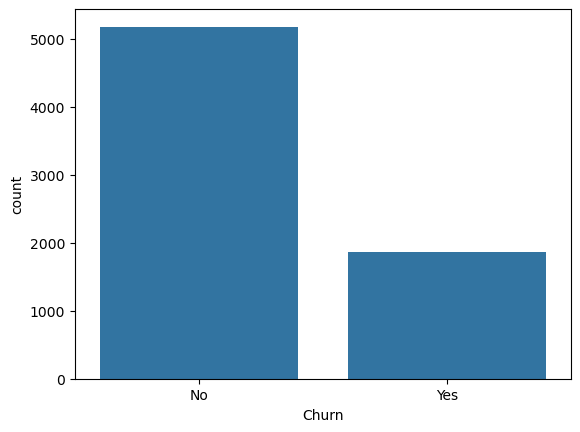

In [13]:
sns.countplot(x="Churn", data=df)
plt.show()

## Remove Unnecessary Column

In [15]:
df.drop("customerID", axis=1, inplace=True)

## Handle TotalCharges Column

In [17]:
df["TotalCharges"].dtype

dtype('O')

In [18]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [19]:
df["TotalCharges"].isnull().sum()

11

## Fill missing values:

In [21]:
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

## Encode Target Variable

In [23]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [24]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## Encode Categorical Columns

In [26]:
categorical_cols = df.select_dtypes(
    include=["object"]
).columns

print(categorical_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [27]:
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [28]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## Create Features and Target

In [30]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

## Train-Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 30)
(1409, 30)
(5634,)
(1409,)


## Train Logistic Regression

In [35]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

LogisticRegression()

## Prediction:

In [37]:
y_pred_lr = lr_model.predict(X_test)

## Accuracy:

In [39]:
accuracy_score(y_test, y_pred_lr)

0.8041163946061036

## Classification report:

In [41]:
print(classification_report(
    y_test,
    y_pred_lr
))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



## Confusion matrix:

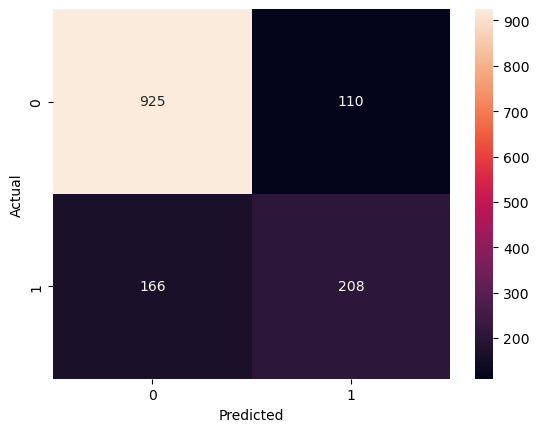

In [43]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Train a Random Forest Model

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Make Predictions

In [47]:
y_pred_rf = rf_model.predict(X_test)

## Check Accuracy

In [49]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_rf)

0.7863733144073811

## Classification Report

In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.77      0.79      0.78      1409



## Confusion Matrix

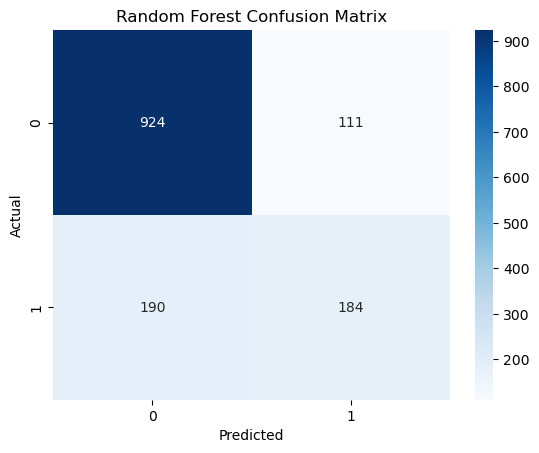

In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

## Compare Both Models

In [55]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Logistic Regression Accuracy :", lr_accuracy)
print("Random Forest Accuracy       :", rf_accuracy)

Logistic Regression Accuracy : 0.8041163946061036
Random Forest Accuracy       : 0.7863733144073811


## Feature Importance

In [57]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
3,TotalCharges,0.192096
1,tenure,0.174733
2,MonthlyCharges,0.168413
28,PaymentMethod_Electronic check,0.038771
10,InternetService_Fiber optic,0.038641
25,Contract_Two year,0.030176
4,gender_Male,0.028321
13,OnlineSecurity_Yes,0.028191
26,PaperlessBilling_Yes,0.025617
5,Partner_Yes,0.023326


## Visualize Top 10 Features

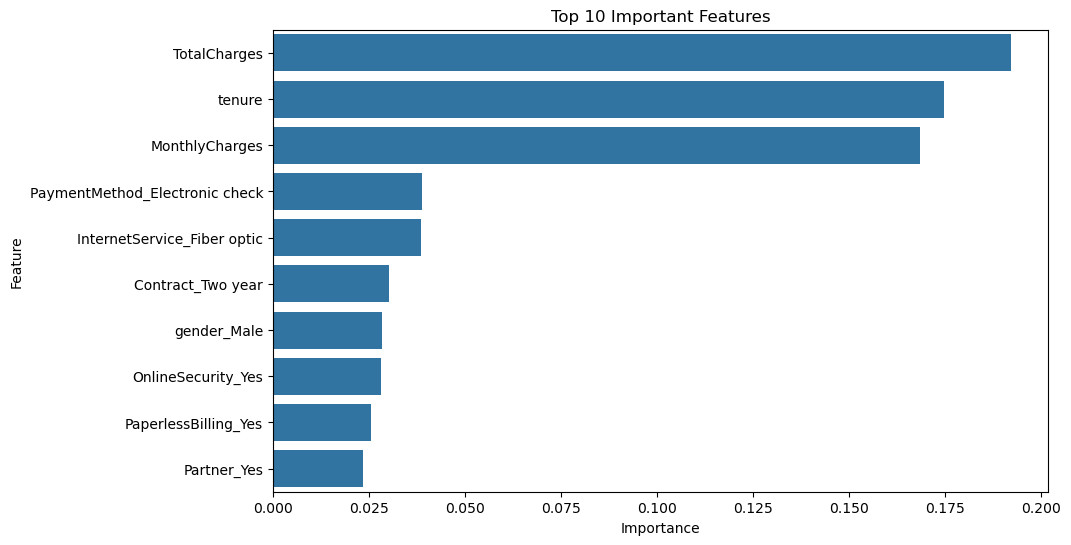

In [59]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

## Save the Model

In [61]:
import pickle

pickle.dump(
    rf_model,
    open("customer_churn_model.pkl", "wb")
)

## Hyperparameter Tuning

In [63]:
RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

RandomForestClassifier(random_state=42)

## Import GridSearchCV

In [65]:
from sklearn.model_selection import GridSearchCV

## Define Parameters

In [67]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

## Create GridSearch Object

In [69]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

## Train

In [71]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

## Best Parameters

In [73]:
print(grid_search.best_params_)

{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


## Best Accuracy

In [75]:
print(grid_search.best_score_)

0.8008496440509945


## Train the Best Model

In [77]:
best_rf = grid_search.best_estimator_

## Predict

In [79]:
y_pred_best = best_rf.predict(X_test)

## Accuracy

In [81]:
accuracy_score(y_test, y_pred_best)

0.8034066713981547


## Classification Report

In [83]:
print(classification_report(
    y_test,
    y_pred_best
))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



## Confusion Matrix

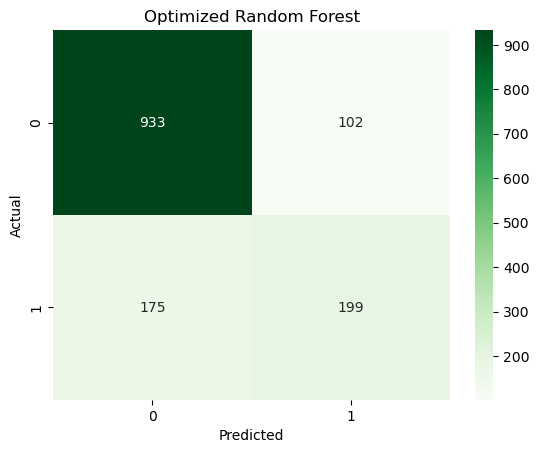

In [85]:
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Optimized Random Forest")
plt.show()

## ROC-AUC Curve

In [87]:
from sklearn.metrics import roc_curve, roc_auc_score

## Get prediction probabilities

In [89]:
y_prob = best_rf.predict_proba(X_test)[:, 1]

## Calculate AUC

In [91]:
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.8412384716732543


## Plot ROC Curve

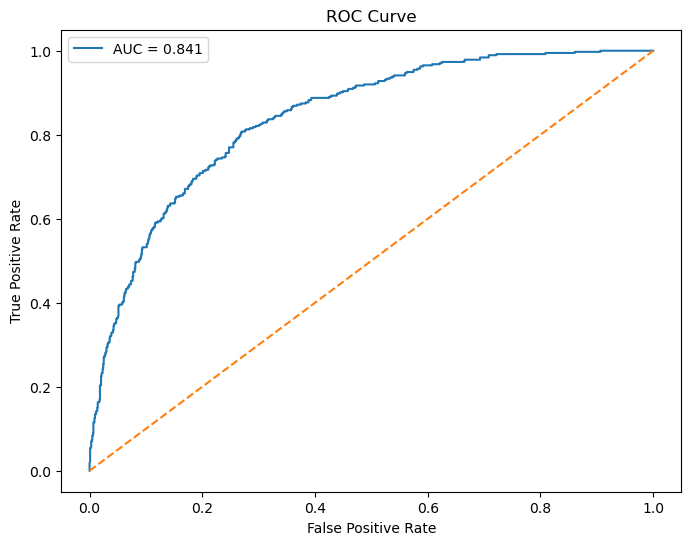

In [93]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

## Save the Optimized Model

In [95]:
import pickle

pickle.dump(
    best_rf,
    open("customer_churn_best_model.pkl", "wb")
)

In [96]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [97]:
selected_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "Contract",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"
]

df = df[selected_features]

In [98]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [99]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [100]:
categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "Contract",
    "PaymentMethod"
]

numerical_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

In [101]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

In [102]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [103]:
pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [105]:
pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'TechSupport', 'Contract',
                                                   'PaymentMethod'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [106]:
from sklearn.metrics import accuracy_score

y_pred = pipeline.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.7672107877927609


In [107]:
import joblib

joblib.dump(
    pipeline,
    "customer_churn_pipeline.joblib"
)

['customer_churn_pipeline.joblib']